# Notebook Julien Kordes Data Challenge IAA

In [145]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
import xgboost as xgb
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from mllab import *

Charger les données:

In [146]:
x_train = pd.read_csv("X_train_Wwou3IE.csv", index_col='DELIVERY_START')
x_test = pd.read_csv("X_test_GgyECq8.csv", index_col = 'DELIVERY_START')
y_train = pd.read_csv("y_train_jJtXgMX.csv", index_col = 'DELIVERY_START').dropna()
x_train.index = pd.to_datetime(x_train.index)
x_test.index = pd.to_datetime(x_test.index)
y_train.index = pd.to_datetime(y_train.index)

In [147]:
print(x_train.columns)

(10605, 9)
(4942, 9)
(10605, 1)
Index(['load_forecast', 'coal_power_available', 'gas_power_available',
       'nucelear_power_available', 'wind_power_forecasts_average',
       'solar_power_forecasts_average', 'wind_power_forecasts_std',
       'solar_power_forecasts_std', 'predicted_spot_price'],
      dtype='object')


Preprocessing de y pour la classification binaire :

In [185]:
y_train_binary = y_train.applymap(lambda x: 1 if x >= 0 else -1)

In [221]:
X1_train, X1_test, Y1_train, Y1_test = train_test_split(x_train, y_train_binary, test_size=0.2, random_state=42, shuffle=True)

# Tests pour sélectionner le classifieur le plus performant sur nos données

In [9]:
def selection_variables_X(X, str):
    return X[str]
def retire_variable_X(X, str):
    return X.drop(str, axis=1)
list_var = ['load_forecast', 'coal_power_available', 'gas_power_available',
       'nucelear_power_available', 'wind_power_forecasts_average',
       'solar_power_forecasts_average', 'wind_power_forecasts_std',
       'solar_power_forecasts_std', 'predicted_spot_price']

In [105]:
classifier = RandomForestClassifier(n_estimators = 150, bootstrap = False ,random_state=42, max_depth = 30, max_features = 'sqrt')
'''classifier = xgb.XGBClassifier(
    objective= 'binary:logistic', 
    eval_metric='logloss',  
    n_estimators = 200,
    max_depth=50,
)'''
#base_estimator = DecisionTreeClassifier(max_depth=15)
#classifier = AdaBoostClassifier(estimator=base_estimator, n_estimators=300, random_state=42)
classifier.fit(X1_train, Y1_train.squeeze())
y_pred = classifier.predict(X1_test)
accuracy_XY = accuracy_score(Y1_test, y_pred)
print(accuracy_XY)

0.7774634606317775


In [85]:
rf_model = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [50, 80, 100, 150, 200, 300],        
    'max_depth': [None, 10, 20, 30, 50, 70],                  
    'max_features': [None, 'sqrt', 'log2'],  
    'bootstrap' : [True, False]        
}

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, 
                           scoring='accuracy', cv=5, n_jobs=-1, verbose=1)

grid_search.fit(X1_train, Y1_train.squeeze())

print("Meilleurs paramètres:", grid_search.best_params_)
print("Meilleure précision:", grid_search.best_score_)

best_model = grid_search.best_estimator_
print(best_model)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Meilleurs paramètres: {'bootstrap': False, 'max_depth': 30, 'max_features': 'sqrt', 'n_estimators': 150}
Meilleure précision: 0.7492931477301787
RandomForestClassifier(bootstrap=False, max_depth=30, n_estimators=150,
                       random_state=42)


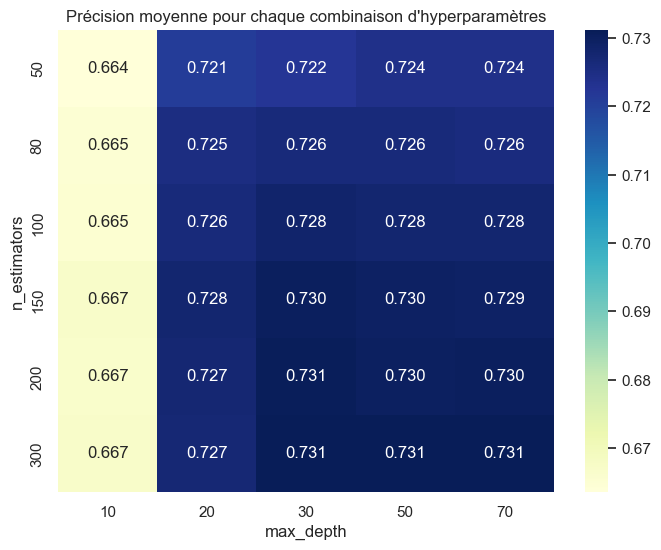

In [86]:
param1 = 'param_n_estimators'
param2 = 'param_max_depth'

results = pd.DataFrame(grid_search.cv_results_)
# Calculer la moyenne des scores pour chaque combinaison d'hyperparamètres
results_mean = results.groupby(['param_n_estimators', 'param_max_depth'])['mean_test_score'].mean().reset_index()

# Transformer en table pivot
pivot_table = results_mean.pivot(index="param_n_estimators", columns="param_max_depth", values="mean_test_score")

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("Précision moyenne pour chaque combinaison d'hyperparamètres")
plt.xlabel("max_depth")
plt.ylabel("n_estimators")
plt.show()

In [89]:
param_grid = {
    'max_depth': [3, 4, 5, 10, 50, 80, 100],
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0]
}

xgb_classifier = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss')

grid_search = GridSearchCV(estimator=xgb_classifier, param_grid=param_grid, scoring='accuracy', cv=3, verbose=1, n_jobs=-1)

grid_search.fit(X1_train, Y1_train)

print("Meilleurs paramètres:", grid_search.best_params_)
print("Meilleure précision:", grid_search.best_score_)

best_model = grid_search.best_estimator_
print(best_model)

Fitting 3 folds for each of 252 candidates, totalling 756 fits
Meilleurs paramètres: {'learning_rate': 0.1, 'max_depth': 50, 'n_estimators': 100, 'subsample': 1.0}
Meilleure précision: 0.7278406412069778
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=50,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)


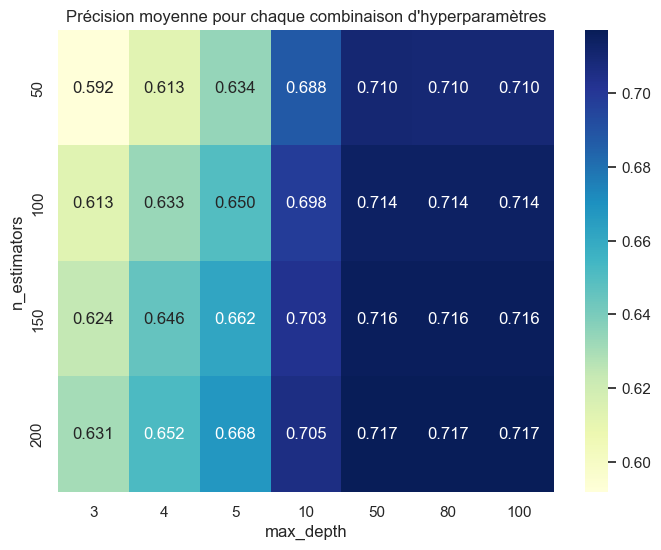

In [90]:
param1 = 'param_n_estimators'
param2 = 'param_max_depth'

results = pd.DataFrame(grid_search.cv_results_)
# Calculer la moyenne des scores pour chaque combinaison d'hyperparamètres
results_mean = results.groupby(['param_n_estimators', 'param_max_depth'])['mean_test_score'].mean().reset_index()

# Transformer en table pivot
pivot_table = results_mean.pivot(index="param_n_estimators", columns="param_max_depth", values="mean_test_score")

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("Précision moyenne pour chaque combinaison d'hyperparamètres")
plt.xlabel("max_depth")
plt.ylabel("n_estimators")
plt.show()

Recherche de corrélation spatiale entre les variables de X :

In [ ]:
for i in range(len(list_var)):
    for j in range(len(list_var)):
        if i != j:
            X = selection_variables_X(X1_train,[list_var[i], list_var[j]]).to_numpy()
            plotXY(X, Y1_train.squeeze())
            plt.show()

Test en enlevant certaines variables de X

Accuracy: 0.7774634606317775 with all variables
Accuracy: 0.5077793493635078 with variable load_forecast
Accuracy: 0.49316360207449317 with variable coal_power_available
Accuracy: 0.5511551155115512 with variable gas_power_available
Accuracy: 0.6973125884016973 with variable nucelear_power_available
Accuracy: 0.4912776991984913 with variable wind_power_forecasts_average
Accuracy: 0.49222065063649223 with variable solar_power_forecasts_average
Accuracy: 0.5058934464875059 with variable wind_power_forecasts_std
Accuracy: 0.4898632720414899 with variable solar_power_forecasts_std
Accuracy: 0.5073078736445074 with variable predicted_spot_price
L'accuracy max de 0.7774634606317775 est atteinte en gardant toutes les variables


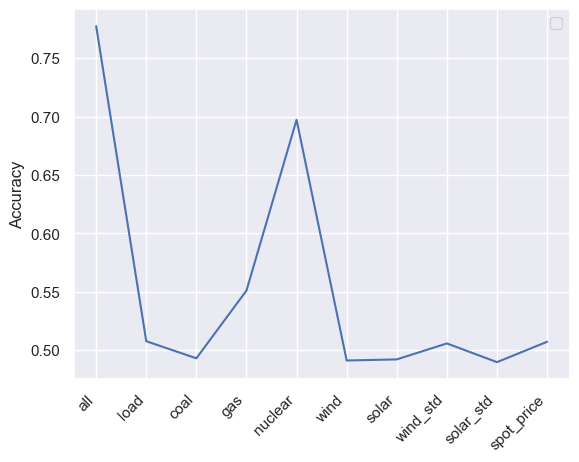

In [107]:
accuracy = [accuracy_XY]
print(f"Accuracy: {accuracy_XY} with all variables")
for i in range(len(list_var)):
    x_train_reduced = selection_variables_X(X1_train, [list_var[i]])
    x_test_reduced = selection_variables_X(X1_test, [list_var[i]])
    classifier = RandomForestClassifier(n_estimators = 150, bootstrap = False ,random_state=42, max_depth = 30, max_features = 'sqrt')
    classifier.fit(x_train_reduced, Y1_train.squeeze())
    y_pred = classifier.predict(x_test_reduced)
    acc = accuracy_score(Y1_test, y_pred)
    accuracy.append(acc)
    print(f"Accuracy: {acc} with variable {list_var[i]}")

maximum = max(accuracy)
ind = accuracy.index(maximum)
if ind == 0 :
    print(f"L'accuracy max de {maximum} est atteinte en gardant toutes les variables")
else:
    print(f"L'accuracy max de {maximum} est atteinte pour la variable {list_var[ind-1]}")
plt.plot(accuracy)
labels = ['all', 'load', 'coal', 'gas', 'nuclear', 'wind', 'solar', 'wind_std', 'solar_std', 'spot_price']
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45, ha='right')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Accuracy: 0.7774634606317775 with all variables
Accuracy: 0.7586044318717586 without variable load_forecast
Accuracy: 0.7675624705327676 without variable coal_power_available
Accuracy: 0.7425742574257426 without variable gas_power_available
Accuracy: 0.7105139085337105 without variable nucelear_power_available
Accuracy: 0.7468175388967468 without variable wind_power_forecasts_average
Accuracy: 0.7755775577557755 without variable solar_power_forecasts_average
Accuracy: 0.7694483734087695 without variable wind_power_forecasts_std
Accuracy: 0.776991984912777 without variable solar_power_forecasts_std
Accuracy: 0.7732201791607732 without variable predicted_spot_price
L'accuracy max de 0.7774634606317775 est atteinte en gardant toutes les variables


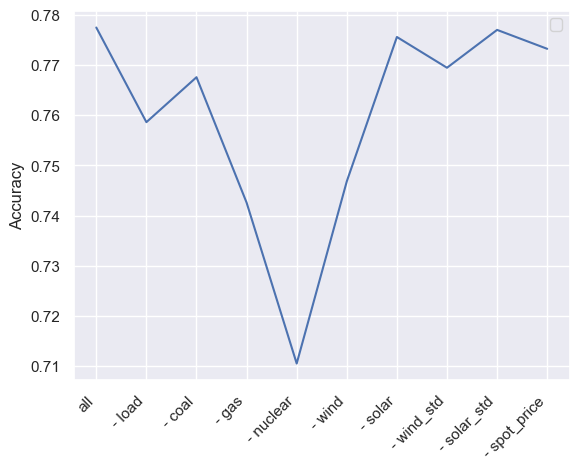

In [108]:
accuracy = [accuracy_XY]
print(f"Accuracy: {accuracy_XY} with all variables")
for i in range(len(list_var)):
    x_train_reduced = retire_variable_X(X1_train, [list_var[i]])
    x_test_reduced = retire_variable_X(X1_test, [list_var[i]])
    classifier = RandomForestClassifier(n_estimators = 150, bootstrap = False ,random_state=42, max_depth = 30, max_features = 'sqrt')
    classifier.fit(x_train_reduced, Y1_train.squeeze())
    y_pred = classifier.predict(x_test_reduced)
    acc = accuracy_score(Y1_test, y_pred)
    accuracy.append(acc)
    print(f"Accuracy: {acc} without variable {list_var[i]}")

maximum = max(accuracy)
ind = accuracy.index(maximum)
if ind == 0 :
    print(f"L'accuracy max de {maximum} est atteinte en gardant toutes les variables")
else:
    print(f"L'accuracy max de {maximum} est atteinte en enlevant uniquement la variable {list_var[ind-1]}")
plt.plot(accuracy)
labels = ['all', '- load', '- coal', '- gas', '- nuclear', '- wind', '- solar', '- wind_std', '- solar_std', ' - spot_price']
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45, ha='right')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [553]:
classifier = RandomForestClassifier(n_estimators = 150, bootstrap = False ,random_state=42, max_depth = 30, max_features = 'sqrt')
'''classifier = xgb.XGBClassifier(
    objective= 'binary:logistic', 
    eval_metric='logloss',  
    n_estimators = 100,
    max_depth=50,
)'''
#base_estimator = DecisionTreeClassifier(max_depth=15)
#classifier = AdaBoostClassifier(estimator=base_estimator, n_estimators=300, random_state=42)

classifier.fit(X1_train, Y1_train.squeeze())


RandomForestClassifier(bootstrap=False, max_depth=30, n_estimators=150,
                       random_state=42)

In [554]:
#y_pred = classifier.predict(X1_test)

# Prédire les probabilités pour la classe positive
y_proba = classifier.predict_proba(X1_test)[:, 1]

# Définir un seuil ajusté
seuil = 0.35  # Ajustez ce seuil selon vos besoins

# Classifier en fonction du nouveau seuil
y_pred_adjusted = np.where(y_proba >= seuil, 1, -1)

accuracy = accuracy_score(Y1_test, y_pred_adjusted)
report = classification_report(Y1_test, y_pred_adjusted)

print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(confusion_matrix(Y1_test, y_pred_adjusted))
print(report)

Accuracy: 0.7576614804337577
Classification Report:
[[642 399]
 [115 965]]
              precision    recall  f1-score   support

          -1       0.85      0.62      0.71      1041
           1       0.71      0.89      0.79      1080

    accuracy                           0.76      2121
   macro avg       0.78      0.76      0.75      2121
weighted avg       0.78      0.76      0.75      2121



In [555]:
feature_importances = pd.Series(classifier.feature_importances_, index=x_train.columns)
print(feature_importances.sort_values(ascending=False))

wind_power_forecasts_average     0.196001
nucelear_power_available         0.178029
wind_power_forecasts_std         0.162618
load_forecast                    0.155035
solar_power_forecasts_average    0.085744
solar_power_forecasts_std        0.083253
gas_power_available              0.075734
predicted_spot_price             0.033911
coal_power_available             0.029674
dtype: float64


# Premier modèle de classification binaire avec modèle déterminé précédemment

In [556]:
def classify_bin(X, y, X_test):
    binary_classifier = RandomForestClassifier(n_estimators = 150, bootstrap = False ,random_state=42, max_depth = 30, max_features = 'sqrt')
    '''binary_classifier = xgb.XGBClassifier(
        objective= 'binary:logistic', 
        eval_metric='logloss',  
        n_estimators = 100,
        max_depth=50,
    )'''
    binary_classifier.fit(X, y.squeeze())
    #group_predictions = binary_classifier.predict(X_test)
    y_proba = binary_classifier.predict_proba(X_test)[:, 1]

    # Définir un seuil ajusté
    seuil = 0.35  

    # Classifier en fonction du nouveau seuil
    group_predictions = np.where(y_proba >= seuil, 1, -1)
    
    return group_predictions

In [557]:
final_predictions = classify_bin(x_train, y_train_binary, x_test)
final_predictions = pd.DataFrame(final_predictions, columns = ['spot_id_delta'], index=x_test.index).sort_index()

In [558]:
print(final_predictions)

                           spot_id_delta
DELIVERY_START                          
2023-04-02 00:00:00+02:00              1
2023-04-02 01:00:00+02:00              1
2023-04-02 02:00:00+02:00             -1
2023-04-02 03:00:00+02:00             -1
2023-04-02 04:00:00+02:00             -1
...                                  ...
2023-10-24 19:00:00+02:00              1
2023-10-24 20:00:00+02:00              1
2023-10-24 21:00:00+02:00              1
2023-10-24 22:00:00+02:00              1
2023-10-24 23:00:00+02:00              1

[4942 rows x 1 columns]


Déterminer la proportion de valeurs positives et négatives :

In [559]:
# Calculer la proportion de valeurs positives et négatives
positives = (final_predictions['spot_id_delta'] > 0).sum()
negatives = (final_predictions['spot_id_delta'] < 0).sum()
zero_count = (final_predictions['spot_id_delta'] == 0).sum()
total_count = final_predictions['spot_id_delta'].count()

positive_proportion = positives / total_count
negative_proportion = negatives / total_count
zero_proportion = zero_count / total_count

# Afficher les résultats
print(f"Proportion de valeurs positives: {positive_proportion:.2%}")
print(f"Proportion de valeurs négatives: {negative_proportion:.2%}")
print(f"Proportion de valeurs égales à zéro: {zero_proportion:.2%}")


Proportion de valeurs positives: 80.19%
Proportion de valeurs négatives: 19.81%
Proportion de valeurs égales à zéro: 0.00%


In [560]:
final_predictions['DELIVERY_START'] = x_test.index
final_predictions = final_predictions[['DELIVERY_START', 'spot_id_delta']]
final_predictions = final_predictions.reset_index(drop=True)
print(final_predictions)

                DELIVERY_START  spot_id_delta
0    2023-04-02 00:00:00+02:00              1
1    2023-04-02 01:00:00+02:00              1
2    2023-04-02 02:00:00+02:00             -1
3    2023-04-02 03:00:00+02:00             -1
4    2023-04-02 04:00:00+02:00             -1
...                        ...            ...
4937 2023-10-24 19:00:00+02:00              1
4938 2023-10-24 20:00:00+02:00              1
4939 2023-10-24 21:00:00+02:00              1
4940 2023-10-24 22:00:00+02:00              1
4941 2023-10-24 23:00:00+02:00              1

[4942 rows x 2 columns]


Convertir les prédictions en CSV

In [562]:
final_predictions.to_csv('y_pred_bin_RFopti_proba035_sans_fill.csv', index=False)

In [579]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

Test d'une PCA :

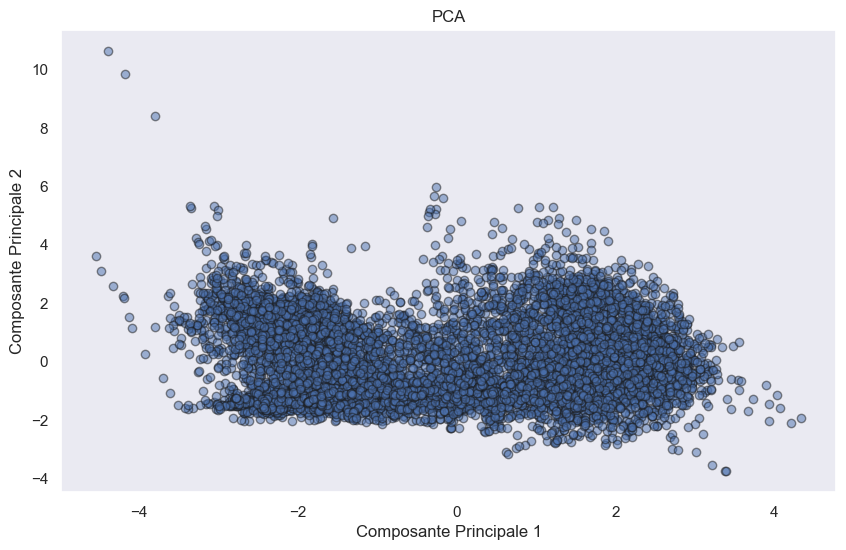

Variance expliquée par la PC1: 0.35
Variance expliquée par la PC2: 0.18


In [580]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x_train.fillna(x_train.mean()))

pca = PCA(n_components=2)  
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

plt.figure(figsize=(10, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], alpha=0.5, edgecolors='k')
plt.title('PCA')
plt.xlabel('Composante Principale 1')
plt.ylabel('Composante Principale 2')
plt.grid()
plt.show()

explained_variance = pca.explained_variance_ratio_
print(f'Variance expliquée par la PC1: {explained_variance[0]:.2f}')
print(f'Variance expliquée par la PC2: {explained_variance[1]:.2f}')



Test Régression sur les données:

In [581]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


if isinstance(y_train, pd.DataFrame):
    y_train = y_train.iloc[:, 0]

x_train_split, x_test_split, y_train_split, y_test_split = train_test_split(x_train, y_train, test_size=0.2, random_state=42)
rf_regressor = RandomForestRegressor(n_estimators=300, random_state=42)
rf_regressor.fit(x_train_split, y_train_split)
y_pred = rf_regressor.predict(x_test_split)
mse = mean_squared_error(y_test_split, y_pred)
r2 = r2_score(y_test_split, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")


Mean Squared Error: 430.671697120553
R² Score: 0.5738729574601819


# Modèle multiclassifcation

Fonction pour faire varier les intervalles (qui correspondent aux classes):

In [502]:
def discretize_dataframe(series, nb_classes):
    # Assurer que l'entrée est une série
    min_value = series.min()
    max_value = series.max()

    # Créer des bornes linéaires serrées autour de 0
    num_fine_bins = nb_classes // 2 # Nombre de classes autour de 0
    fine_bins = np.linspace(-40, 40, num=num_fine_bins  + 1)  # Ajuste l'intervalle autour de 0

    # Créer des bornes larges à l'extérieur
    outer_bins_count = nb_classes - num_fine_bins
    outer_bins_positive = np.linspace(40, 150, num=(outer_bins_count // 2))[1:]  # Bornes positives
    outer_bins_negative = np.linspace(-40, -150, num=(outer_bins_count - outer_bins_positive.size ))[:-1]  # Bornes négatives

    # Fusionner les bornes
    bins = np.concatenate([np.array([min_value]), outer_bins_negative, fine_bins, outer_bins_positive, np.array([max_value + 1])])
    
    # Ajouter 0 à la liste des bornes, s'il n'est pas déjà présent
    bins = np.sort(np.unique(np.concatenate([bins, [0]])))  # Assurer que 0 est inclus et que les bornes sont uniques

    print(bins)

    # Appliquer la discrétisation
    discretized_series = pd.cut(series, bins=bins, labels=range(len(bins) - 1), right=False)
    return discretized_series.to_frame(), bins

In [503]:
y_train_discretized, bins = discretize_dataframe(y_train['spot_id_delta'], 4)
y_train_discretized['spot_id_delta'] = y_train_discretized['spot_id_delta'].astype(int)
print(set(y_train_discretized['spot_id_delta']))

[-1567.35354675   -40.             0.            40.
   659.96132937]
{0, 1, 2, 3}


In [504]:
X2_train, X2_test, Y2_train, Y2_test = train_test_split(x_train, y_train_discretized, test_size=0.2, random_state=42, shuffle=True)

In [505]:
def classify_multi_RandomForest(X_train, y_train, X_test):
    ''' classifier = xgb.XGBClassifier(
    objective='multi:softmax',  
    num_class= 10, 
    eval_metric='mlogloss', 
    n_estimators = n_estimators,
    max_depth = 100
    ) '''  

    classifier = RandomForestClassifier(n_estimators = 150, bootstrap = False ,random_state=42)
    classifier.fit(X_train, y_train)
    y_proba = classifier.predict_proba(X_test)
    pred = np.argmax(y_proba, axis=1)
    pred = np.where((y_proba[:, 0] > 0.2) & (y_proba[:, 3] != 0) & (y_proba[:, 0] - y_proba[:, 3] < 0.2), 1, pred) 
    pred = np.where((y_proba[:, 3] > 0.2) & (y_proba[:, 3] != 0) & (y_proba[:, 0] - y_proba[:, 3] > 0.2), 2, pred) 
    return pred

In [506]:
predictions_train = classify_multi_RandomForest(X2_train ,Y2_train ,X2_train)
predictions_test = classify_multi_RandomForest(X2_train ,Y2_train ,X2_test)

In [507]:
predictions_train = pd.DataFrame(predictions_train, columns = ['spot_id_delta'], index=X2_train.index).sort_index()
predictions_test = pd.DataFrame(predictions_test, columns = ['spot_id_delta'], index=X2_test.index).sort_index() 

In [508]:
print(classification_report(Y2_test, predictions_test))
print(confusion_matrix(Y2_test, predictions_test))

              precision    recall  f1-score   support

           0       0.01      0.01      0.01       103
           1       0.43      0.46      0.44       938
           2       0.44      0.44      0.44       950
           3       0.03      0.02      0.03       130

    accuracy                           0.40      2121
   macro avg       0.23      0.23      0.23      2121
weighted avg       0.39      0.40      0.40      2121

[[  1  47  50   5]
 [ 40 432 423  43]
 [ 35 456 421  38]
 [  3  71  53   3]]


In [509]:
y_residus_train = predictions_train[(predictions_train['spot_id_delta'] == 1) | (predictions_train['spot_id_delta'] == 2)]
y_residus_test = predictions_test[(predictions_test['spot_id_delta'] == 1) | (predictions_test['spot_id_delta'] == 2)]
y_binary_residus = y_train_binary.loc[y_train_binary.index.isin(y_residus_train.index)]

In [510]:
X1_train_residus = X1_train.loc[X1_train.index.intersection(y_residus_train.index)] 
X1_test_residus = X1_test.loc[X1_test.index.intersection(y_residus_test.index)]
Y1_test_residus = Y1_test.loc[Y1_test.index.intersection(y_residus_test.index)]
print(X1_train_residus.shape)
print(y_residus_train.shape)  

(7500, 9)
(7500, 1)


In [511]:
pred_residus = classify_bin(X1_train_residus,  y_binary_residus, X1_test_residus)
print(classification_report(Y1_test_residus, pred_residus))
print(confusion_matrix(Y1_test_residus, pred_residus))

              precision    recall  f1-score   support

          -1       0.49      0.17      0.26       964
           1       0.51      0.82      0.63       989

    accuracy                           0.50      1953
   macro avg       0.50      0.50      0.44      1953
weighted avg       0.50      0.50      0.44      1953

[[167 797]
 [174 815]]


In [512]:
pred_residus = pd.DataFrame(pred_residus, columns = ['spot_id_delta'], index=X1_test_residus.index).sort_index()
print(pred_residus)

                           spot_id_delta
DELIVERY_START                          
2022-01-01 02:00:00+01:00              1
2022-01-01 05:00:00+01:00              1
2022-01-01 10:00:00+01:00             -1
2022-01-01 12:00:00+01:00              1
2022-01-01 16:00:00+01:00             -1
...                                  ...
2023-03-28 22:00:00+02:00              1
2023-03-29 08:00:00+02:00              1
2023-03-29 13:00:00+02:00              1
2023-03-29 17:00:00+02:00              1
2023-03-29 22:00:00+02:00              1

[1953 rows x 1 columns]


In [513]:
predictions_test.update(pred_residus)

In [514]:
predictions_test.replace(0, -1, inplace=True)

In [515]:
print(predictions_test)

                           spot_id_delta
DELIVERY_START                          
2022-01-01 02:00:00+01:00              1
2022-01-01 05:00:00+01:00              1
2022-01-01 10:00:00+01:00             -1
2022-01-01 12:00:00+01:00              1
2022-01-01 16:00:00+01:00             -1
...                                  ...
2023-03-28 22:00:00+02:00              1
2023-03-29 08:00:00+02:00              1
2023-03-29 13:00:00+02:00              1
2023-03-29 17:00:00+02:00              1
2023-03-29 22:00:00+02:00              1

[2121 rows x 1 columns]


# Faire tourner le modèle d'un coup :

In [179]:
predictions_train = classify_multi_RandomForest(x_train ,y_train_discretized ,x_train)
predictions_test = classify_multi_RandomForest(x_train ,y_train_discretized ,x_test)
predictions_train = pd.DataFrame(predictions_train, columns = ['spot_id_delta'], index=x_train.index).sort_index()
predictions_test = pd.DataFrame(predictions_test, columns = ['spot_id_delta'], index=x_test.index).sort_index() 
y_residus_train = predictions_train[(predictions_train['spot_id_delta'] == 1) | (predictions_train['spot_id_delta'] == 2)]
y_residus_test = predictions_test[(predictions_test['spot_id_delta'] == 1) | (predictions_test['spot_id_delta'] == 2)]
x_train_residus = x_train.loc[x_train.index.intersection(y_residus_train.index)] 
x_test_residus = x_test.loc[x_test.index.intersection(y_residus_test.index)]
y_binary_residus = y_train_binary.loc[y_train_binary.index.intersection(y_residus_train.index)]
pred_residus = classify_bin(x_train_residus,  y_binary_residus, x_test_residus)
pred_residus = pd.DataFrame(pred_residus, columns = ['spot_id_delta'], index=x_test_residus.index).sort_index()
predictions_test.update(pred_residus)
predictions_test.replace(3, 1, inplace=True)
predictions_test.replace(0, -1, inplace=True)
print(predictions_test)

                           spot_id_delta
DELIVERY_START                          
2023-04-02 00:00:00+02:00              1
2023-04-02 01:00:00+02:00              1
2023-04-02 02:00:00+02:00             -1
2023-04-02 03:00:00+02:00             -1
2023-04-02 04:00:00+02:00             -1
...                                  ...
2023-10-24 19:00:00+02:00              1
2023-10-24 20:00:00+02:00             -1
2023-10-24 21:00:00+02:00              1
2023-10-24 22:00:00+02:00              1
2023-10-24 23:00:00+02:00              1

[4942 rows x 1 columns]


Déterminer la proportion de prédictions positives et négatives

In [563]:
# Calculer la proportion de valeurs positives et négatives
positives = (predictions_test['spot_id_delta'] == 1).sum()
negatives = (predictions_test['spot_id_delta'] == -1).sum()
total_count = predictions_test['spot_id_delta'].count()

positive_proportion = positives / total_count
negative_proportion = negatives / total_count
zero_proportion = zero_count / total_count

# Afficher les résultats
print(f"Proportion de valeurs positives: {positive_proportion:.2%}")
print(f"Proportion de valeurs négatives: {negative_proportion:.2%}")

Proportion de valeurs positives: 76.00%
Proportion de valeurs négatives: 19.80%


In [549]:
predictions_test['DELIVERY_START'] = x_test.index
predictions_test = predictions_test[['DELIVERY_START', 'spot_id_delta']]
predictions_test = predictions_test.reset_index(drop=True)
print(predictions_test)

                DELIVERY_START  spot_id_delta
0    2023-04-02 00:00:00+02:00              1
1    2023-04-02 01:00:00+02:00              1
2    2023-04-02 02:00:00+02:00             -1
3    2023-04-02 03:00:00+02:00             -1
4    2023-04-02 04:00:00+02:00             -1
...                        ...            ...
4937 2023-10-24 19:00:00+02:00              1
4938 2023-10-24 20:00:00+02:00              1
4939 2023-10-24 21:00:00+02:00              2
4940 2023-10-24 22:00:00+02:00              2
4941 2023-10-24 23:00:00+02:00              2

[4942 rows x 2 columns]


Convertir les prédictions en CSV

In [550]:
predictions_test.to_csv('y_pred_sans_fill_multi_4+binproba0.30.csv', index=False)